# Demo 09 - End-to-end integration: surface, eSSVI handoff, local vol, and PDE repricing

This notebook runs a compact end-to-end pass over the shared scenario: surface diagnostics and repair, smooth eSSVI handoff, local-vol construction, and PDE repricing. It is a short integration view of the workflow, with the fuller analysis kept in Demos 06-08.

- summarize the repaired surface stage
- summarize the smooth implied-surface handoff
- summarize local-vol diagnostics, PDE anchor checks, and repricing
- point to the deeper notebooks for each stage

`PROFILE = "quick"` keeps the integration pass short.

In [ ]:
# ruff: noqa: E402
from __future__ import annotations

import sys
from pathlib import Path


def _find_repo_root(start: Path) -> Path:
    for candidate in (start, *start.parents):
        if (candidate / 'src' / 'option_pricing').exists():
            return candidate
    return start

ROOT = _find_repo_root(Path.cwd())
SRC = ROOT / 'src'
if SRC.exists() and str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

PROFILE = 'quick'
SEED = 7

,profile,surface_repair_mode,dupire_ready_surface,repricing_surface_type,gj_benchmark_loaded
0,quick,robust_all_line_search,ESSVISmoothedSurface,ESSVISmoothedSurface,True


In [ ]:
import matplotlib.pyplot as plt  # noqa: E402
import pandas as pd  # noqa: E402
from IPython.display import display  # noqa: E402

from option_pricing.demos import run_surface_to_localvol_pde_integration  # noqa: E402
from option_pricing.diagnostics.vol_surface import plot as vs_plot  # noqa: E402

pd.set_option('display.max_columns', None)

art = run_surface_to_localvol_pde_integration(profile=PROFILE, seed=SEED)

summary = pd.DataFrame(
    [
        {
            'profile': art.profile,
            'surface_repair_mode': art.meta['surface_demo']['svi_repair_mode_used'],
            'dupire_ready_surface': art.meta['essvi_bridge']['dupire_ready_surface'],
            'repricing_surface_type': art.meta['localvol_pde_demo']['repricing_target_surface_type'],
            'gj_benchmark_loaded': art.gj51 is not None,
        }
    ]
)
display(summary)

## 1) Surface diagnostics and repair summary

This stage keeps one headline view of no-arbitrage status, repair outcomes, and the reference benchmark; Demo 06 contains the fuller surface and interpolation analysis.

,surface,ok,calendar_ok,calendar_max_violation,message
0,truth_grid (latent benchmark),True,True,0.000000,"OK, mono_bad=0/11, butterfly_bad=0/11, calenda..."
1,grid (observed quotes),False,True,0.000000,"Violations found, mono_bad=0/11, butterfly_bad..."
2,svi_no_repair,False,False,0.032524,"Violations found, mono_bad=0/11, butterfly_bad..."
3,svi_repaired,False,False,0.032524,"Violations found, mono_bad=0/11, butterfly_bad..."


,stage,ok,min_g,min_g_plot,argmin_plot,lee_ok,params,failure_reason
0,before_repair,False,-1.036017e-02,0.046145,1.25,False,"SVIParams(a=-0.03796155644103699, b=1.04667692...","wing_limit_violation (gL_inf=0.25, gR_inf=-0.0..."
1,after_repair,True,-9.999968e-11,0.146496,1.25,True,"SVIParams(a=-0.05311322764695281, b=0.88018504...",None


,stage,ok,min_g,failure_reason
0,orig,False,-3.286357e-02,g_below_floor
1,projected,True,2.534913e-01,None
2,optimal,True,-9.434344e-11,None


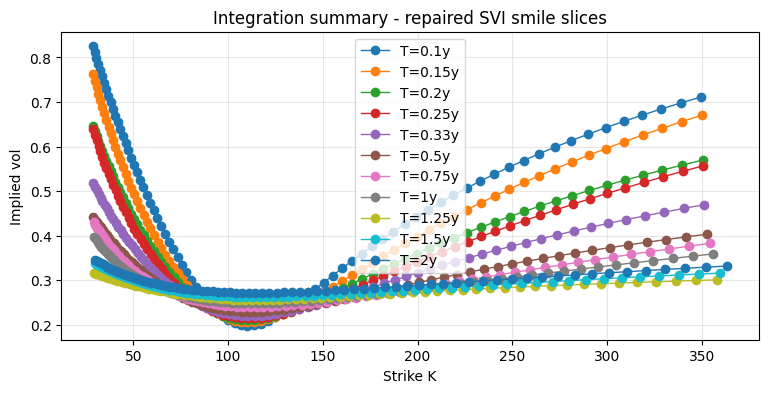

In [2]:
display(
    art.tables['surface_noarb_summary'][
        ['surface', 'ok', 'calendar_ok', 'calendar_max_violation', 'message']
    ]
)
display(art.tables['explicit_repair_summary'])
if art.gj51 is not None:
    display(art.tables['gj51_checks'])
else:
    print('GJ paper sanity check disabled for this run.')

vs_plot.plot_smile_slices(
    art.surfaces['svi_repaired'],
    forward=art.scenario.forward,
    title='Integration summary - repaired SVI smile slices',
)

## 2) Smooth implied-surface handoff summary

This stage keeps the projection, time-smoothness comparison, and local-vol handoff visible without repeating the fuller node and fit discussion from Demo 07.

,fit_success,price_rmse,max_abs_price_error,node_validation_ok,projection_success,projection_validation_ok,projection_dupire_invalid_count,projection_total_points,projection_message
0,True,0.024943,0.114532,True,True,True,0,930,OK


,T_knot,max_abs_wT_jump_svi,mean_abs_wT_jump_svi,max_abs_wT_jump_smoothed,mean_abs_wT_jump_smoothed,max_jump_ratio_svi_over_smoothed
0,0.15,0.080696,0.041167,0.000082,0.000043,988.288624
1,0.20,0.046021,0.025094,0.000027,0.000013,1719.239926
2,0.25,0.050251,0.024871,0.000024,0.000017,2052.203917
3,0.33,0.060117,0.031881,0.000013,0.000008,4612.528670
4,0.50,0.043331,0.025605,0.000012,0.000008,3609.975893
5,0.75,0.030832,0.016916,0.000012,0.000006,2644.112350
6,1.00,0.015677,0.009221,0.000009,0.000006,1751.398179
7,1.25,0.016616,0.008183,0.000009,0.000006,1814.817340
8,1.50,0.013674,0.006932,0.000010,0.000007,1388.958106


,invalid_count,invalid_frac,sigma_min,sigma_median,sigma_max,denom_abs_min
0,0,0.0,0.208672,0.277583,0.30931,0.547313


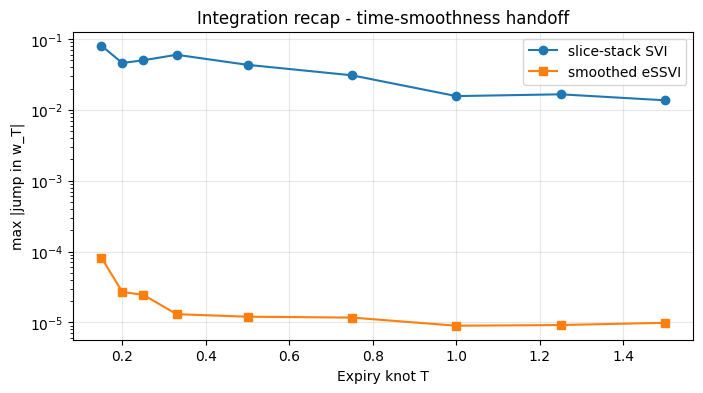

In [3]:
smoothness = art.tables['essvi_time_smoothness_compare'].copy()
smoothness['max_jump_ratio_svi_over_smoothed'] = (
    smoothness['max_abs_wT_jump_svi'] / smoothness['max_abs_wT_jump_smoothed']
)

display(art.tables['essvi_projection_summary'])
display(smoothness)
display(art.tables['essvi_localvol_handoff_summary'])

plt.figure(figsize=(8, 4))
plt.semilogy(
    smoothness['T_knot'],
    smoothness['max_abs_wT_jump_svi'],
    marker='o',
    label='slice-stack SVI',
)
plt.semilogy(
    smoothness['T_knot'],
    smoothness['max_abs_wT_jump_smoothed'],
    marker='s',
    label='smoothed eSSVI',
)
plt.xlabel('Expiry knot T')
plt.ylabel('max |jump in w_T|')
plt.title('Integration recap - time-smoothness handoff')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## 3) Local-vol and PDE repricing summary

The final stage keeps the local-vol diagnostic headline, PDE anchor tables, repricing summary, and convergence grid together; Demo 08 contains the fuller diagnostics and pricing inspection.

,invalid_count,invalid_frac,sigma_min,sigma_median,sigma_max,denom_abs_min
0,0,0.0,0.208563,0.283886,0.357416,0.455086


,method,advection,Nx,Nt,n,abs_err_mean,abs_err_max,runtime_ms_mean,feasible_rate
0,rannacher,central,101,201,1,0.000002,0.000002,82.7004,1.0


,n_options,mean_abs_price_error,max_abs_price_error,mean_abs_iv_error_bp,max_abs_iv_error_bp,mean_runtime_ms,total_runtime_ms,Nx,Nt
0,30,0.403512,1.219317,342.219695,1028.471031,901.3775,27131.2826,101,201


,Nx,Nt,grid_points,pde_price,target_price,abs_error,runtime_ms
0,101,201,20301,9.482389,9.92812,0.445731,1255.7971
1,151,301,45451,9.485606,9.92812,0.442514,1736.2019
2,201,401,80601,9.486811,9.92812,0.441309,2192.7924


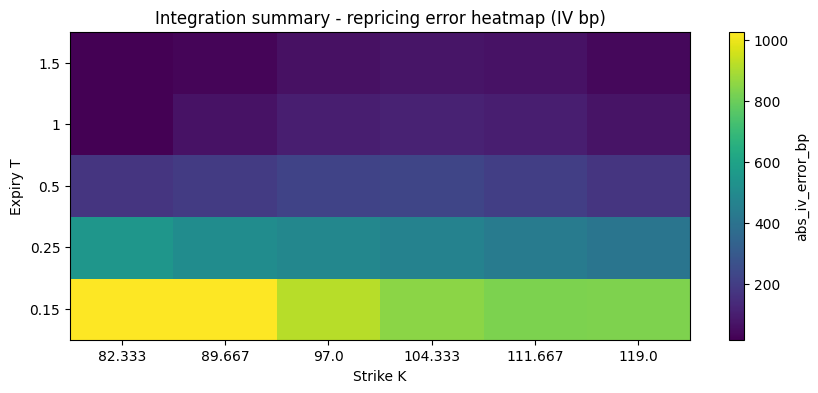

In [4]:
display(art.tables['localvol_summary'])
display(art.tables['pde_anchor_grouped'])
display(art.tables['repricing_summary'])
display(art.tables['convergence_grid'])

vs_plot.plot_repricing_heatmap(
    art.tables['repricing_grid'],
    value_col='abs_iv_error_bp',
    title='Integration summary - repricing error heatmap (IV bp)',
)

## Use this notebook when...

- use Demo 09 for a compact end-to-end workflow view
- use Demo 06 for static surface diagnostics, SVI repair, and interpolation choices
- use Demo 07 for the smooth implied-surface handoff and expiry-direction smoothness
- use Demo 08 for local-vol diagnostics, PDE validation, and repricing detail